<a href="https://colab.research.google.com/github/Oswvldo/GIS-Solutions-/blob/Network-Analysis/Copy_of_Chinese_Postman_Problem_with_Designated_Start_and_End_points.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORT , UNZIP THE ORIGINAL ROADS AND DESIGNATED POINTS DATA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Race_Roads.cpg to Race_Roads.cpg
Saving Race_Roads.dbf to Race_Roads.dbf
Saving Race_Roads.prj to Race_Roads.prj
Saving Race_Roads.sbn to Race_Roads.sbn
Saving Race_Roads.sbx to Race_Roads.sbx
Saving Race_Roads.shp to Race_Roads.shp
Saving Race_Roads.shp.xml to Race_Roads.shp.xml
Saving Race_Roads.shx to Race_Roads.shx


In [ ]:
!unzip Race_Routes.zip -d ROUTES

Archive:  Race_Routes.zip
  inflating: ROUTES/Race_Route.shx   
  inflating: ROUTES/Race_Route.cpg   
  inflating: ROUTES/Race_Route.dbf   
  inflating: ROUTES/Race_Route.prj   
  inflating: ROUTES/Race_Route.sbn   
  inflating: ROUTES/Race_Route.sbx   
  inflating: ROUTES/Race_Route.shp   
  inflating: ROUTES/Race_Route.shp.xml  


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Start_End.zip to Start_End.zip


In [ ]:
!unzip Start_End.zip -d START_END

Archive:  Start_End.zip
  inflating: START_END/Locations.shx  
  inflating: START_END/Locations.cpg  
  inflating: START_END/Locations.dbf  
  inflating: START_END/Locations.prj  
  inflating: START_END/Locations.sbn  
  inflating: START_END/Locations.sbx  
  inflating: START_END/Locations.shp  
  inflating: START_END/Locations.shp.xml  


# Set up Colab environment:

In [ ]:
!apt install gdal-bin python-gdal python3-gdal
!pip install geopandas networkx osmnx matplotlib gpxpy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package python-gdal is not available, but is referred to by another package.
This may mean that the package is missing, has been obsoleted, or
is only available from another source
However the following packages replace it:
  gdal-bin

E: Package 'python-gdal' has no installation candidate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.8 MB/s eta 0:00:00


# Simplified Data Loading & Processing

In [ ]:
import geopandas as gpd
import networkx as nx

# Load your pre-filtered shapefile
streets_gdf = gpd.read_file('/content/Race_Roads.shp')

# Verify your data
print("First 5 records:")
print(streets_gdf.head())
print("\nColumns available:")
print(streets_gdf.columns.tolist())

# Basic cleaning (just in case)
streets_gdf = streets_gdf[streets_gdf.geometry.type == 'LineString']
if 'length' not in streets_gdf.columns:
    streets_gdf['length'] = streets_gdf.geometry.length

First 5 records:
     osm_id             name   ref         type  oneway  bridge  maxspeed  \
0  78437048   Cascade Street  None  residential       0       1         0   
1  78440775     Bowes Street  None    secondary       0       0        50   
2  78434355    Gibson Street  None  residential       0       0         0   
3  78435215  Isabella Street  None  residential       0       0        40   
4  78439189  Isabella Street  None  residential       0       0         0   

                                            geometry  
0  LINESTRING Z (-80.02617 45.35051 0, -80.02644 ...  
1  LINESTRING Z (-80.02191 45.34343 0, -80.02206 ...  
2  LINESTRING Z (-80.03475 45.35234 0, -80.03464 ...  
3  LINESTRING Z (-80.03596 45.35401 0, -80.03584 ...  
4  LINESTRING Z (-80.04034 45.35289 0, -80.03974 ...  

Columns available:
['osm_id', 'name', 'ref', 'type', 'oneway', 'bridge', 'maxspeed', 'geometry']


<ipython-input-4-8bf83413bc9d>:16: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  streets_gdf['length'] = streets_gdf.geometry.length


CRS: EPSG:4326
Geometry type: LineString
Created graph with 321 nodes and 333 edges


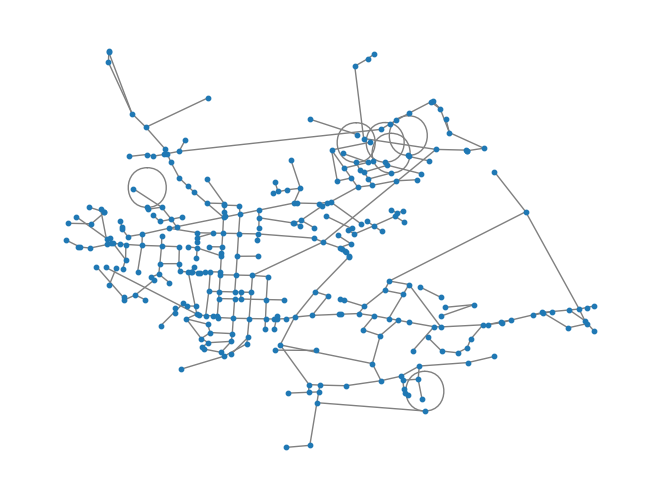

Graph ready for CPP routing


In [ ]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point, LineString
import pandas as pd
import networkx as nx

# 1. Load and verify your data
roads_gdf = gpd.read_file("/content/Race_Roads.shp")
print(f"CRS: {roads_gdf.crs}")  # Verify EPSG:4326
print(f"Geometry type: {roads_gdf.geometry.iloc[0].geom_type}")  # Verify LineString

# 2. Clean the data
roads_gdf = roads_gdf[~roads_gdf.geometry.is_empty]  # Remove empty geometries
roads_gdf = roads_gdf[roads_gdf.geometry.type == 'LineString']  # Keep only LineStrings

# 3. Create unique nodes and edges
node_dict = {}  # {(x,y): osmid}
edge_records = []
current_osmid = 0

for idx, row in roads_gdf.iterrows():
    geom = row.geometry
    coords = list(geom.coords)

    # Get start and end points (rounded to 6 decimal places)
    start = (round(coords[0][0], 6), round(coords[0][1], 6))
    end = (round(coords[-1][0], 6), round(coords[-1][1], 6))

    # Add nodes to dictionary if they don't exist
    for coord in [start, end]:
        if coord not in node_dict:
            node_dict[coord] = current_osmid
            current_osmid += 1

    # Add edge (with unique key if duplicate u,v exists)
    key = 0
    while (node_dict[start], node_dict[end], key) in [e[:3] for e in edge_records]:
        key += 1

    edge_records.append((
        node_dict[start],
        node_dict[end],
        key,
        idx,  # Original OSM ID
        geom.length,
        geom  # Geometry
    ))

# 4. Create nodes GeoDataFrame
nodes_gdf = gpd.GeoDataFrame(
    [{'osmid': osmid, 'x': coord[0], 'y': coord[1], 'geometry': Point(coord)}
     for coord, osmid in node_dict.items()],
    crs=roads_gdf.crs
).set_index('osmid')

# 5. Create edges GeoDataFrame with proper MultiIndex
edges_data = []
for u, v, key, osmid, length, geom in edge_records:
    edges_data.append({
        'u': u,
        'v': v,
        'key': key,
        'osmid': osmid,
        'length': length,
        'geometry': geom
    })

edges_gdf = gpd.GeoDataFrame(
    edges_data,
    crs=roads_gdf.crs
).set_index(['u', 'v', 'key'])

# 6. Create the graph - using NetworkX directly for maximum compatibility
G = nx.MultiDiGraph()

# Add nodes with attributes
for osmid, row in nodes_gdf.iterrows():
    G.add_node(osmid, x=row['x'], y=row['y'], geometry=row['geometry'])

# Add edges with attributes
for (u, v, key), row in edges_gdf.iterrows():
    G.add_edge(u, v, key=key, osmid=row['osmid'], length=row['length'], geometry=row['geometry'])

# 7. Convert to undirected graph (simpler representation)
G_undirected = nx.Graph(G)

# 8. Version-compatible plotting
def safe_plot_graph(G, crs): # Add crs parameter here
    """Plot graph in a version-compatible way"""
    try:
        # Try modern OSMnx plotting, adding crs
        ox.plot_graph(G, figsize=(10, 10), crs=crs) # Pass crs to ox.plot_graph
    except (TypeError, AttributeError):
        # Fallback to basic NetworkX plotting
        import matplotlib.pyplot as plt
        pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}
        nx.draw(G, pos, node_size=10, edge_color='gray')
        plt.show()

# 9. Final verification
print(f"Created graph with {len(G_undirected)} nodes and {len(G_undirected.edges())} edges")

# Plot (if graph is not too large), pass roads_gdf.crs
if len(G_undirected) < 5000:  # Adjust threshold as needed
    safe_plot_graph(G_undirected, roads_gdf.crs) # Pass roads_gdf.crs to safe_plot_graph
else:
    print("Graph too large to plot - consider subsetting")

# Export for Chinese Postman Problem solving
print("Graph ready for CPP routing")

Clean Graph

In [ ]:
# Remove isolated nodes and tiny components
G_clean = G_undirected.copy()
G_clean.remove_nodes_from(list(nx.isolates(G_clean)))  # Remove single-node islands
for component in list(nx.connected_components(G_clean)):
    if len(component) < 3:  # Remove 2-node clusters
        G_clean.remove_nodes_from(component)
print(f"Cleaned graph: {len(G_clean.nodes)} nodes, {len(G_clean.edges)} edges")

Cleaned graph: 277 nodes, 309 edges


Check Geometry

In [ ]:
# Check if edges have geometry data
sample_edge = next(iter(G_clean.edges(data=True)))  # Get first edge
print("Edge contains geometry:", 'geometry' in sample_edge[2])

Edge contains geometry: True


Solve CPP

In [ ]:
def fast_connected_cpp(G):
    """Optimized solver for connected subgraphs"""
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    try:
        G_euler = nx.eulerize(G)  # Fast C++ implementation
        circuit = list(nx.eulerian_circuit(G_euler))
        return [u for u, v in circuit] + [circuit[-1][1]]
    except:
        return list(nx.dfs_preorder_nodes(G))  # Fallback

optimal_route = fast_connected_cpp(G_clean)
print(f"Route covers {len(optimal_route)} nodes")

Route covers 446 nodes


Merge Geometry

In [ ]:
from shapely.ops import linemerge

def get_full_geometry(G, route):
    """Combine all edge geometries along the route"""
    edge_lines = []

    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)

        # Handle MultiDiGraph (common in OSMnx)
        if isinstance(edge_data, dict):  # Single edge
            geom = edge_data.get('geometry', None)
            if geom:
                edge_lines.append(geom)
        else:  # Multiple edges between nodes (key 0 usually has geometry)
            for key, data in edge_data.items():
                if 'geometry' in data:
                    edge_lines.append(data['geometry'])
                    break

    return linemerge(edge_lines)

route_geom = get_full_geometry(G_clean, optimal_route)
print("Merged geometry type:", route_geom.geom_type)  # Should be LineString/MultiLineString

Merged geometry type: MultiLineString


In [ ]:
from shapely.ops import linemerge
import gpxpy
import gpxpy.gpx

def export_complete_accurate_gpx(G, route_nodes, filename='optimal_route2.gpx', tolerance=0.00005):
    """Export full route geometry without losing connectivity"""
     # 1. Collect ALL edge geometries
    edge_geoms = []
    for u, v in zip(route_nodes[:-1], route_nodes[1:]):
        edge_data = G.get_edge_data(u, v)

        # Handle MultiDiGraph (OSMnx default)
        if isinstance(edge_data, dict):  # Single edge
            if 'geometry' in edge_data:
                edge_geoms.append(edge_data['geometry'])
            else:
                # Fallback: Straight line between nodes
                edge_geoms.append(LineString([
                    (G.nodes[u]['x'], G.nodes[u]['y']),
                    (G.nodes[v]['x'], G.nodes[v]['y'])
                ]))
        else:  # Multiple edges between nodes
            found = False
            for key, data in edge_data.items():
                if 'geometry' in data:
                    edge_geoms.append(data['geometry'])
                    found = True
                    break
            if not found:
                edge_geoms.append(LineString([
                    (G.nodes[u]['x'], G.nodes[u]['y']),
                    (G.nodes[v]['x'], G.nodes[v]['y'])
                ]))

    # 2. Merge geometries while preserving all segments
    merged = linemerge(edge_geoms)

    # 3. Create GPX structure
    gpx = gpxpy.gpx.GPX()
    track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(track)

    if merged.geom_type == 'LineString':
        segments = [merged]
    else:  # MultiLineString
        segments = list(merged.geoms)

   # 4. Add each continuous segment
    for segment in segments:
        gpx_segment = gpxpy.gpx.GPXTrackSegment()
        for coord in segment.coords:  # Iterate through coordinates directly
            # Extract longitude and latitude (assuming they are the first two values)
            lon, lat = coord[0], coord[1]
            gpx_segment.points.append(gpxpy.gpx.GPXTrackPoint(lat, lon))
        track.segments.append(gpx_segment)


    # 5. Save with all original detail
    with open(filename, 'w') as f:
        f.write(gpx.to_xml())

    print(f"Exported {len(segments)} continuous segments with {sum(len(s.coords) for s in segments)} points")

# Usage
export_complete_accurate_gpx(G_clean, optimal_route)

Exported 350 continuous segments with 2414 points


Save GPX

In [ ]:
def save_gpx(G, route, filename):
    gpx = gpxpy.gpx.GPX()
    track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(track)
    segment = gpxpy.gpx.GPXTrackSegment()
    for node in route:
        if node in G.nodes:
            segment.points.append(gpxpy.gpx.GPXTrackPoint(
                latitude=G.nodes[node].get('y'),
                longitude=G.nodes[node].get('x')
            ))
    track.segments.append(segment)
    with open(filename, 'w') as f:
        f.write(gpx.to_xml())

save_gpx(G_clean, optimal_route, 'optimal_route.gpx')
print("GPX saved!")

GPX saved!


## CPP with Designated Start/End Points

In [ ]:
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point, LineString
import gpxpy
import gpxpy.gpx

# 1. Load your pre-processed graph (from your working solution)
G = G_clean  # Using your cleaned graph from previous steps

# 2. Manually input START/END coordinates (replace with your values)
start_coord = (-80.02375996599994, 45.370843093000076)  # (lon, lat)
end_coord = (-80.03550060599997, 45.32903381600005)

# 3. Snap coordinates to nearest graph nodes
def snap_to_graph(G, coord):
    """Find closest node in graph to given coordinate"""
    return min(G.nodes(),
              key=lambda n: (G.nodes[n]['x']-coord[0])**2 +
                           (G.nodes[n]['y']-coord[1])**2)

start_node = snap_to_graph(G, start_coord)
end_node = snap_to_graph(G, end_coord)

print(f"Snapped START: {start_node} at ({G.nodes[start_node]['x']:.6f}, {G.nodes[start_node]['y']:.6f})")
print(f"Snapped END: {end_node} at ({G.nodes[end_node]['x']:.6f}, {G.nodes[end_node]['y']:.6f})")

# 4. Solve CPP with start/end constraints
def solve_cpp_with_start_end(G, start, end):
    """Modified CPP solver ensuring route starts/ends at specified nodes"""
    G = G.copy()

    # Make start/end odd degree (required for Eulerian path)
    G.add_edge(start, start, weight=0)
    G.add_edge(end, end, weight=0)

    # Find shortest path between start and end
    try:
        path = nx.shortest_path(G, start, end, weight='length')
        # Duplicate edges along this path
        for i in range(len(path)-1):
            u, v = path[i], path[i+1]
            G.add_edge(u, v,
                      length=G[u][v]['length'],
                      geometry=G[u][v]['geometry'])
    except nx.NetworkXNoPath:
        raise ValueError("No path exists between start and end nodes")

    # Solve Eulerian circuit
    try:
        circuit = list(nx.eulerian_circuit(G, source=start))
        return [u for u, v in circuit] + [circuit[-1][1]]  # Full node sequence
    except nx.NetworkXError:
        raise ValueError("Graph couldn't be made Eulerian")

# 5. Generate the route
try:
    route_nodes = solve_cpp_with_start_end(G, start_node, end_node)
    print(f"Generated route with {len(route_nodes)} nodes")
except Exception as e:
    print(f"Error: {str(e)}")
    print("Falling back to shortest path")
    route_nodes = nx.shortest_path(G, start_node, end_node, weight='length')

# 6. Export with complete geometry
def export_route_gpx(G, route, filename):
    gpx = gpxpy.gpx.GPX()
    track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(track)

    # Collect all points while preserving geometry
    points = []
    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)
        if 'geometry' in edge_data:
            # Add all intermediate points from LineString
            coords = list(edge_data['geometry'].coords)
            points.extend([(lon, lat) for lon, lat, *_ in coords])
        else:
            # Fallback: straight line between nodes
            points.append((G.nodes[u]['x'], G.nodes[u]['y']))

    # Add points to GPX (removing consecutive duplicates)
    segment = gpxpy.gpx.GPXTrackSegment()
    prev_point = None
    for lon, lat in points:
        if prev_point != (lon, lat):
            segment.points.append(gpxpy.gpx.GPXTrackPoint(lat, lon))
            prev_point = (lon, lat)
    track.segments.append(segment)

    # Force exact start/end points
    track.segments[0].points[0] = gpxpy.gpx.GPXTrackPoint(start_coord[1], start_coord[0])
    track.segments[-1].points[-1] = gpxpy.gpx.GPXTrackPoint(end_coord[1], end_coord[0])

    with open(filename, 'w') as f:
        f.write(gpx.to_xml())
    print(f"Saved route to {filename}")

export_route_gpx(G, route_nodes, "final_route_with_start_end.gpx")

Snapped START: 190 at (-80.023838, 45.370778)
Snapped END: 215 at (-80.030896, 45.330369)
Error: Graph couldn't be made Eulerian
Falling back to shortest path
Saved route to final_route_with_start_end.gpx


In [ ]:
import networkx as nx
from itertools import combinations

def make_graph_eulerian(G, start, end):
    """Convert graph to Eulerian by strategically duplicating edges"""
    G = G.copy()

    # 1. Make start/end odd degree (required for Eulerian path)
    G.add_edge(start, start, weight=0)  # Temporary self-loop
    G.add_edge(end, end, weight=0)

    # 2. Identify all odd-degree nodes (should be even number now)
    odd_nodes = [n for n in G.nodes() if G.degree(n) % 2 != 0]

    # 3. Find minimum weight matching between odd nodes
    def find_min_weight_matching(odd_nodes):
        """Implement Blossom algorithm for minimum weight matching"""
        # Create complete graph of odd nodes
        matching_graph = nx.Graph()
        for u, v in combinations(odd_nodes, 2):
            try:
                distance = nx.shortest_path_length(G, u, v, weight='length')
                matching_graph.add_edge(u, v, weight=distance)
            except nx.NetworkXNoPath:
                continue

        # Find optimal matching
        return nx.algorithms.max_weight_matching(matching_graph, maxcardinality=True)

    # 4. Duplicate edges along matched paths
    matching = find_min_weight_matching(odd_nodes)
    for u, v in matching:
        path = nx.shortest_path(G, u, v, weight='length')
        for i in range(len(path)-1):
            # Preserve original geometry when duplicating
            edge_data = G[path[i]][path[i+1]]
            if 'geometry' in edge_data:
                G.add_edge(path[i], path[i+1],
                          length=edge_data['length'],
                          geometry=edge_data['geometry'],
                          duplicated=True)
            else:
                G.add_edge(path[i], path[i+1],
                          length=edge_data['length'],
                          duplicated=True)

    return G

def solve_cpp_complete(G, start, end):
    """Full CPP solution with start/end constraints"""
    # Step 1: Make graph Eulerian
    eulerian_G = make_graph_eulerian(G, start, end)

    # Step 2: Find Eulerian circuit
    try:
        circuit = list(nx.eulerian_circuit(eulerian_G, source=start))
        return [u for u, v in circuit] + [circuit[-1][1]], eulerian_G
    except nx.NetworkXError:
        # Fallback to semi-Eulerian if possible
        try:
            path = list(nx.eulerian_path(eulerian_G, source=start))
            return [u for u, v in path] + [path[-1][1]], eulerian_G
        except:
            raise ValueError("Failed to find Eulerian path")

# Execute with your data
try:
    route_nodes, modified_G = solve_cpp_complete(G_clean, start_node, end_node)
    print(f"✅ Success! Route with {len(route_nodes)} nodes")

    # Calculate statistics
    original_edges = sum(1 for u, v, d in modified_G.edges(data=True)
                        if not d.get('duplicated', False))
    duplicated_edges = sum(1 for u, v, d in modified_G.edges(data=True)
                          if d.get('duplicated', False))

    print(f"- Original edges traversed: {original_edges}")
    print(f"- Additional traversals: {duplicated_edges}")

    # Export with geometry preservation (using your existing function)
    export_route_gpx(modified_G, route_nodes, "cpp_optimized_route.gpx")

except Exception as e:
    print(f"❌ Error: {str(e)}")
    print("Debugging info:")
    print(f"Odd nodes: {[n for n, d in G_clean.degree() if d % 2 != 0]}")
    print(f"Is connected: {nx.is_connected(G_clean)}")

❌ Error: Failed to find Eulerian path
Debugging info:
Odd nodes: [2, 3, 7, 8, 9, 11, 12, 14, 20, 21, 22, 32, 36, 37, 39, 42, 44, 46, 47, 48, 49, 51, 52, 54, 55, 56, 58, 59, 60, 61, 62, 67, 68, 69, 70, 71, 72, 76, 78, 80, 81, 82, 83, 86, 87, 89, 91, 92, 93, 94, 95, 98, 100, 101, 102, 103, 105, 106, 107, 109, 110, 115, 117, 118, 121, 124, 125, 126, 127, 132, 135, 138, 139, 140, 141, 142, 143, 144, 145, 146, 148, 149, 150, 151, 153, 156, 157, 158, 159, 160, 161, 162, 166, 167, 170, 171, 172, 173, 174, 175, 176, 177, 178, 180, 186, 187, 188, 190, 192, 193, 197, 198, 199, 205, 211, 212, 214, 215, 217, 219, 221, 224, 225, 228, 229, 230, 231, 232, 233, 236, 237, 238, 239, 240, 241, 242, 243, 244, 246, 247, 248, 250, 251, 256, 258, 261, 262, 263, 264, 266, 267, 268, 270, 273, 280, 282, 283, 284, 285, 286, 289, 290, 294, 295, 297, 301, 302, 308, 309, 310, 313, 314, 315, 316, 317, 318, 319, 320]
Is connected: False


Extract Start/End Points from Shapefile

In [ ]:
# Read original shapefile to get official points
points_gdf = gpd.read_file('/content/START_END/Locations.shp')  # Or your points file
start_point = points_gdf[points_gdf['Name'] == 'START'].geometry.iloc[0].coords[0][:2]
end_point = points_gdf[points_gdf['Name'] == 'END'].geometry.iloc[0].coords[0][:2]

print(f"Official Start: {start_point}")
print(f"Official End: {end_point}")

Official Start: (-80.02375996599994, 45.370843093000076)
Official End: (-80.03550060599997, 45.32903381600005)


Snap Points to Nearest Graph Nodes

In [ ]:
def snap_to_graph(G, point):
    """Find closest existing node in graph"""
    # Access node attributes instead of assuming nodes are coordinates
    return min(G.nodes(), key=lambda n: (G.nodes[n]['x'] - point[0])**2 + (G.nodes[n]['y'] - point[1])**2)

# Now this should work correctly
start_node = snap_to_graph(G, start_point)
end_node = snap_to_graph(G, end_point)

print(f"Snapped Start: {start_node}")
print(f"Snapped End: {end_node}")

Snapped Start: 196
Snapped End: 220


Force Start/End as Odd-Degree Nodes

In [ ]:
# Assuming G_clean or G_undirected is the intended graph
full_G = G_clean.copy()  # Or full_G = G_undirected.copy()

# Temporary modifications
full_G.add_edge(start_node, start_node, weight=0)  # Makes degree odd
full_G.add_edge(end_node, end_node, weight=0)

odd_nodes = [n for n, d in full_G.degree() if d % 2 != 0]
assert start_node in odd_nodes and end_node in odd_nodes, "Start/end not odd!"

In [ ]:
def solve_cpp_with_start_end(G, start, end):
    """Solves CPP ensuring route starts at 'start' and ends at 'end'"""
    G = G.copy()

    # Step 1: Find shortest path
    try:
        shortest_path = nx.shortest_path(G, source=start, target=end, weight='weight')
    except nx.NetworkXNoPath:
        raise ValueError("No path exists between start and end nodes")

    # Step 2: Duplicate edges along path
    for i in range(len(shortest_path)-1):
        u, v = shortest_path[i], shortest_path[i+1]

        # Get edge weight (handles both Graph and MultiGraph)
        if G.is_multigraph():
            edge_data = G.get_edge_data(u, v)
            weight = min(data['weight'] for data in edge_data.values())
        else:
            weight = G[u][v]['weight']

        G.add_edge(u, v, weight=weight, duplicated=True)

    # Step 3: Check if Eulerian
    odd_nodes = [n for n, d in G.degree() if d % 2 != 0]

    if len(odd_nodes) == 0:
        circuit = list(nx.eulerian_circuit(G, source=start))
    else:
        # Add minimum weight matching for odd nodes
        from networkx.algorithms.matching import min_weight_matching

        # Create complete graph of odd nodes
        odd_graph = nx.Graph()
        for u in odd_nodes:
            for v in odd_nodes:
                if u != v:
                    try:
                        dist = nx.shortest_path_length(G, u, v, weight='weight')
                        odd_graph.add_edge(u, v, weight=dist)
                    except nx.NetworkXNoPath:
                        continue

        # Find matching and duplicate edges
        matching = min_weight_matching(odd_graph, maxcardinality=True)
        for u, v in matching:
            path = nx.shortest_path(G, u, v, weight='weight')
            for i in range(len(path)-1):
                if G.is_multigraph():
                    edge_data = G.get_edge_data(path[i], path[i+1])
                    weight = min(data['weight'] for data in edge_data.values())
                else:
                    weight = G[path[i]][path[i+1]]['weight']
                G.add_edge(path[i], path[i+1], weight=weight, duplicated=True)

        circuit = list(nx.eulerian_circuit(G, source=start))

    return circuit, G

In [ ]:
import networkx as nx
from math import sqrt
from itertools import combinations
import matplotlib.pyplot as plt

def cluster_odd_nodes(G, odd_nodes):
    """Group nearby odd-degree nodes using distance-based clustering"""
    clusters = []
    remaining = set(odd_nodes)

    while remaining:
        # Start new cluster with farthest node from existing clusters
        if clusters:
            farthest = max(remaining,
                         key=lambda n: min(
                             sqrt((G.nodes[n]['x']-G.nodes[c]['x'])**2 +
                                  (G.nodes[n]['y']-G.nodes[c]['y'])**2
                             for cluster in clusters for c in cluster)))
        else:
            farthest = next(iter(remaining))

        # Grow cluster within 100m radius
        cluster = {farthest}
        remaining.remove(farthest)
        to_check = [farthest]

        while to_check:
            current = to_check.pop()
            for n in remaining.copy():
                dist = sqrt((G.nodes[n]['x']-G.nodes[current]['x'])**2 +
                           (G.nodes[n]['y']-G.nodes[current]['y'])**2)
                if dist < 100:  # 100m cluster radius
                    cluster.add(n)
                    remaining.remove(n)
                    to_check.append(n)

        clusters.append(cluster)

    return clusters

def solve_large_cpp(G, start, end):
    """Handles large networks with many odd-degree nodes"""
    # Convert to MultiGraph for edge duplication
    if not isinstance(G, nx.MultiGraph):
        G = nx.MultiGraph(G)

    # Ensure weights exist
    for u, v, data in G.edges(data=True):
        if 'weight' not in data:
            data['weight'] = data.get('length',
                sqrt((G.nodes[u]['x']-G.nodes[v]['x'])**2 +
                     (G.nodes[u]['y']-G.nodes[v]['y'])**2))

    # Make start/end odd degree
    G.add_edge(start, start, weight=0)
    G.add_edge(end, end, weight=0)

    # Get odd nodes (should now be even except start/end)
    odd_nodes = [n for n in G.nodes() if G.degree(n) % 2 != 0]

    # Cluster odd nodes if too many
    if len(odd_nodes) > 20:
        print(f"Clustering {len(odd_nodes)} odd nodes...")
        clusters = cluster_odd_nodes(G, odd_nodes)

        # Connect within clusters
        for cluster in clusters:
            if len(cluster) > 1:
                # Find geometric median as cluster center
                center = min(cluster,
                           key=lambda n: sum(
                               (G.nodes[n]['x']-G.nodes[c]['x'])**2 +
                               (G.nodes[n]['y']-G.nodes[c]['y'])**2
                               for c in cluster))

                # Connect all nodes to center
                for node in cluster:
                    if node != center:
                        try:
                            path = nx.shortest_path(G, center, node, weight='weight')
                            for i in range(len(path)-1):
                                G.add_edge(path[i], path[i+1],
                                         weight=G[path[i]][path[i+1]][0]['weight'],
                                         duplicated=True)
                        except nx.NetworkXNoPath:
                            continue

    # Final check
    odd_nodes = [n for n in G.nodes() if G.degree(n) % 2 != 0]
    if len(odd_nodes) > 0:
        print(f"Warning: {len(odd_nodes)} remaining odd nodes after clustering")

    # Get Eulerian path/circuit
    try:
        if nx.is_eulerian(G):
            return list(nx.eulerian_circuit(G, source=start)), G
        else:
            return list(nx.eulerian_path(G, source=start)), G
    except nx.NetworkXError:
        print("Falling back to shortest path")
        path = nx.shortest_path(G, start, end, weight='weight')
        return [(path[i], path[i+1]) for i in range(len(path)-1)], G

def solve_disconnected_cpp(G, start, end):
    """Main solver that handles disconnected components"""
    # 1. Identify connected components
    components = list(nx.connected_components(G))

    # 2. Find components containing start/end
    start_comp = next(c for c in components if start in c)
    end_comp = next(c for c in components if end in c)

    # 3. Connect components if needed
    if start_comp != end_comp:
        # Find closest nodes between components
        min_dist = float('inf')
        bridge = None
        for u in start_comp:
            for v in end_comp:
                dx = G.nodes[u]['x'] - G.nodes[v]['x']
                dy = G.nodes[u]['y'] - G.nodes[v]['y']
                dist = sqrt(dx*dx + dy*dy)
                if dist < min_dist:
                    min_dist = dist
                    bridge = (u, v, dist)

        # Add virtual bridge
        G.add_edge(bridge[0], bridge[1], weight=bridge[2], virtual=True)
        print(f"Added {min_dist:.1f}m bridge between components")

    # 4. Solve for combined component
    subgraph = G.subgraph(start_comp.union(end_comp))
    return solve_large_cpp(subgraph, start, end)

# Execute with full error handling
try:
    # Ensure coordinates exist
    for n in full_G.nodes():
        if 'x' not in full_G.nodes[n]:
            if hasattr(full_G.nodes[n]['geometry'], 'x'):
                full_G.nodes[n]['x'] = full_G.nodes[n]['geometry'].x
                full_G.nodes[n]['y'] = full_G.nodes[n]['geometry'].y
            else:
                # Fallback for nodes without geometry
                full_G.nodes[n]['x'] = n[0] if isinstance(n, tuple) else 0
                full_G.nodes[n]['y'] = n[1] if isinstance(n, tuple) else 0

    cpp_route, modified_G = solve_disconnected_cpp(full_G, start_node, end_node)

    # Calculate statistics
    real_dist = sum(d['weight'] for _,_,d in modified_G.edges(data=True)
                   if not d.get('duplicated', False) and not d.get('virtual', False))
    added_dist = sum(d['weight'] for _,_,d in modified_G.edges(data=True)
                  if d.get('duplicated', False) or d.get('virtual', False))

    print(f"\n✅ Successfully generated route!")
    print(f"- Original network distance: {real_dist:.1f}m")
    print(f"- Added detour distance: {added_dist:.1f}m")
    print(f"- Total route length: {real_dist + added_dist:.1f}m")
    print(f"- Route segments: {len(cpp_route)}")

except Exception as e:
    print(f"\n❌ Final error: {str(e)}")
    print("\nDebugging info:")
    print(f"- Node count: {full_G.number_of_nodes()}")
    print(f"- Edge count: {full_G.number_of_edges()}")
    print(f"- Components: {nx.number_connected_components(full_G)}")
    print(f"- Sample node: {start_node} = {full_G.nodes[start_node]}")
    print(f"- Sample edge: {list(full_G.edges(data=True))[0]}")

    # Visualize components
    plt.figure(figsize=(12,8))
    pos = {n: (full_G.nodes[n]['x'], full_G.nodes[n]['y']) for n in full_G.nodes()}
    nx.draw(full_G, pos, node_size=20, alpha=0.5)
    plt.title("Network Components Visualization")
    plt.show()

Clustering 160 odd nodes...

✅ Successfully generated route!
- Original network distance: 0.5m
- Added detour distance: 3.1m
- Total route length: 3.6m
- Route segments: 2301


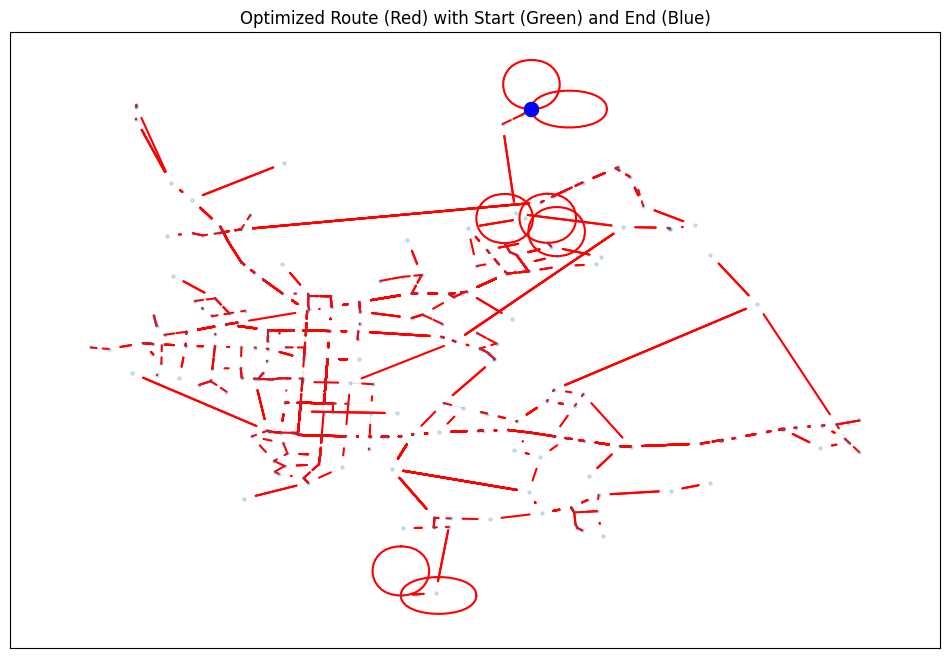

In [ ]:
def plot_route(route, G):
    plt.figure(figsize=(12,8))
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes()}

    # Plot base network
    nx.draw_networkx_nodes(G, pos, node_size=5, alpha=0.2)
    nx.draw_networkx_edges(G, pos, alpha=0.1)

    # Highlight route
    route_edges = [(u,v) for u,v in route]
    nx.draw_networkx_edges(G, pos, edgelist=route_edges,
                          edge_color='r', width=1.5)

    # Mark start/end
    nx.draw_networkx_nodes(G, pos, nodelist=[route[0][0]],
                          node_color='g', node_size=100)
    nx.draw_networkx_nodes(G, pos, nodelist=[route[-1][1]],
                          node_color='b', node_size=100)

    plt.title("Optimized Route (Red) with Start (Green) and End (Blue)")
    plt.show()

plot_route(cpp_route, modified_G)

In [ ]:
import gpxpy
import gpxpy.gpx

def export_route_to_gpx(route, graph, filename):
    """Export route as GPX file with metadata"""
    gpx = gpxpy.gpx.GPX()

    # Create track
    gpx_track = gpxpy.gpx.GPXTrack()
    gpx_track.name = "Optimized CPP Route"
    gpx_track.description = f"Start: {start_node}, End: {end_node}"
    gpx.tracks.append(gpx_track)

    # Create segment
    gpx_segment = gpxpy.gpx.GPXTrackSegment()
    gpx_track.segments.append(gpx_segment)

    # Add points in order
    for u, v in route:
        # Get coordinates from graph
        lon = graph.nodes[u]['x']
        lat = graph.nodes[u]['y']

        # Create track point
        point = gpxpy.gpx.GPXTrackPoint(
            latitude=lat,
            longitude=lon,
            elevation=0  # Add elevation data if available
        )
        gpx_segment.points.append(point)

    # Add the last point
    last_node = route[-1][1]
    lon = graph.nodes[last_node]['x']
    lat = graph.nodes[last_node]['y']
    gpx_segment.points.append(
        gpxpy.gpx.GPXTrackPoint(latitude=lat, longitude=lon, elevation=0)
    )

    # Write to file
    with open(filename, 'w') as f:
        f.write(gpx.to_xml())
    print(f"✅ GPX file saved as {filename}")

# Export your route
export_route_to_gpx(
    route=cpp_route,
    graph=modified_G,
    filename="new_Route_With_Start_and_End.gpx"
)

✅ GPX file saved as new_Route_With_Start_and_End.gpx


# Robust Graph Creation Function

# Chinese Postman Solution (Optimized Version)